# IMPROTING ALL THE NECESSARY LIBRARIES 

In [47]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder


# LOADING THE DATASET

In [10]:
data = pd.read_stata(r"C:\Users\yendi\OneDrive\Desktop\level 3 semester 5\data.dta")

df=pd.DataFrame(data)
df

,age,education,maritalstatus,occupation,beekeeping,otheragripractic,anyfemale,cooperatives,culturalbeliefs,stereotypes,genderroles
0,<35years,secondary and above,married,business,Yes,farming,No,No,Yes,No,Yes
1,>36years,primary,widowed,farmer,Yes,farming,No,Yes,No,No,No
2,>36years,primary,married,farmer,Yes,farming,No,No,Yes,No,No
3,<35years,secondary and above,married,farmer,No,None,Yes,Yes,Yes,No,Yes
4,>36years,primary,widowed,farmer,Yes,livestock production,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...
254,<35years,primary,married,farmer,Yes,livestock production,No,No,No,No,No
255,>36years,primary,widowed,farmer,Yes,farming,No,No,No,No,Yes
256,>36years,primary,married,farmer,Yes,farming,No,No,Yes,No,No
257,<35years,secondary and above,married,farmer,Yes,livestock production,No,No,No,No,Yes


In [11]:
df.describe()

,age,education,maritalstatus,occupation,beekeeping,otheragripractic,anyfemale,cooperatives,culturalbeliefs,stereotypes,genderroles
count,259,259,259,259,259,259,259,259,259,259,259
unique,2,2,3,3,2,3,2,2,2,2,2
top,>36years,primary,married,farmer,Yes,farming,No,No,Yes,No,Yes
freq,141,160,111,197,168,125,196,192,156,199,139


## A.Produce a table showing summary of all study independent variables. The table should have n, % and 95% CI for %.

In [13]:
def calculate_percentage_and_ci(series):
    n= len(series)
    count = series.value_counts().get('yes',0)
    proportion = count / n
    lower_ci, upper_ci = proportion_confint(count,n,alpha=0.05,method ='wilson')
    return n, proportion * 100 ,lower_ci*100, upper_ci*100



In [20]:
summary_data = []
for column in df.columns:
    n, percentage, lower_ci, upper_ci = calculate_percentage_and_ci(df[column])
    summary_data.append({
        'Variable': column,
        'n': n,
        '%': percentage,
        '95% CI Lower': lower_ci,
        '95% CI Upper': upper_ci
    })

In [31]:
summary_df = pd.DataFrame(summary_data)
print("SUMMARY TABLE")
print(summary_df)

SUMMARY TABLE
            Variable  n           %  95% CI Lower  95% CI Upper
0                age  3    0.000000      0.000000     56.149703
1          education  3    0.000000      0.000000     56.149703
2      maritalstatus  3    0.000000      0.000000     56.149703
3         occupation  3    0.000000      0.000000     56.149703
4         beekeeping  3  100.000000     43.850297    100.000000
5   otheragripractic  3    0.000000      0.000000     56.149703
6          anyfemale  3    0.000000      0.000000     56.149703
7       cooperatives  3   33.333333      6.149194     79.234040
8    culturalbeliefs  3   66.666667     20.765960     93.850806
9        stereotypes  3    0.000000      0.000000     56.149703
10       genderroles  3   33.333333      6.149194     79.234040


#  B. Produce a pie chart for beekeeping status with title below the figure.

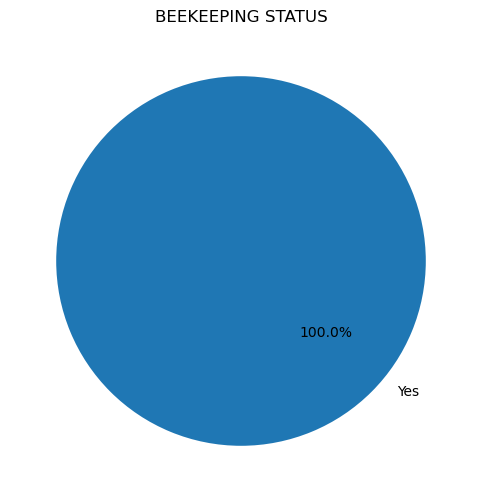

In [29]:
beekeeping_counts = df['beekeeping'].value_counts()
plt.figure(figsize = (8,6))
plt.pie(beekeeping_counts , labels = beekeeping_counts.index,autopct='%1.1f%%', startangle=140)
plt.title('BEEKEEPING STATUS') 
plt.show()

# C.  Produce a table for bivariate association of beekeeping status and each of the independent variables

In [42]:
def chi_square_test(column1,column2):
    contingency_table =pd.crosstab(column1,column2)
    chi2,p,dof,ex = chi2_contingency(contingency_table)
    n =contingency_table.sum().sum()
    phi2 = chi2/n
    r,k =contingency_table.shape
    cramer_v = np.sqrt(phi2 / min(k-1, r-1))
    return chi2 ,dof,p,cramer_v


In [50]:
bivariate_association_data =[]
for column in df.columns:
    if column !='beekeeping':
        chi2 ,dof ,p,cramer_v = chi_square_test(df['beekeeping'], df[column])
        bivariate_association_data.append({
            'Variable': column,
            'Chi Square': chi2,
            'df': dof,
            'p value': p,
            'Cramer\'s V': cramer_v
        })

C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / min(k-1, r-1))
C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / min(k-1, r-1))
C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / min(k-1, r-1))
C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / min(k-1, r-1))
C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / min(k-1, r-1))
C:\Users\yendi\AppData\Local\Temp\ipykernel_11540\3793659094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cramer_v = np.sqrt(phi2 / m

In [49]:
bivariate_association_df = pd.DataFrame(bivariate_association_data)
print("BIVARIATE ASSOCIATION TABLE")
print(bivariate_association_df)

BIVARIATE ASSOCIATION TABLE
           Variable  Chi Square  df  p value  Cramer's V
0               age         0.0   0      1.0         NaN
1         education         0.0   0      1.0         NaN
2     maritalstatus         0.0   0      1.0         NaN
3        occupation         0.0   0      1.0         NaN
4  otheragripractic         0.0   0      1.0         NaN
5         anyfemale         0.0   0      1.0         NaN
6      cooperatives         0.0   0      1.0         NaN
7   culturalbeliefs         0.0   0      1.0         NaN
8       stereotypes         0.0   0      1.0         NaN
9       genderroles         0.0   0      1.0         NaN
